<a href="https://colab.research.google.com/github/Darakhshannazir/streaming-subscriber-ltv-system/blob/main/01_data_features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Netflix -  Data Features**

**Installing & Importing libraries**

In [ ]:
!pip install pandas numpy scikit-learn xgboost shap \
             lifelines econml umap-learn sentence-transformers \
             mlflow kaggle plotly -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 1.3 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.6/40.6 kB 944.9 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 409.1/409.1 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 64.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 27.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 63.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 34.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.3/117.3 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os, warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print("Libraries imported")

Libraries imported


# Step # 1 Downloading MovieLens 25M dataset

In [ ]:
!wget -q "https://files.grouplens.org/datasets/movielens/ml-25m.zip"
!unzip -q ml-25m.zip
print("MovieLens 25M downloaded")

# Load core files
ratings = pd.read_csv('ml-25m/ratings.csv')
movies  = pd.read_csv('ml-25m/movies.csv')

print(f"Ratings: {ratings.shape}")
print(f"Movies:  {movies.shape}")
ratings.head()
movies.head()

MovieLens 25M downloaded
Ratings: (25000095, 4)
Movies:  (62423, 3)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


# Step # 2 Data Cleaning

In [ ]:
# Subset
user_counts = ratings.groupby('userId').size()
active_users = user_counts[user_counts >= 10].index

# 50K users
n_sample = min(20_000, len(active_users))
sampled_users = np.random.choice(active_users, size=n_sample, replace=False)

# Filter down
ratings = ratings[ratings['userId'].isin(sampled_users)].copy()

# Convert timestamps
ratings['timestamp'] = pd.to_datetime(ratings['timestamp'], unit='s')

# Merge with movies
df = ratings.merge(movies, on='movieId', how='left')
df['genre_primary'] = df['genres'].str.split('|').str[0]

print(f"Working dataset: {df.shape}")
print(f"Unique users: {df['userId'].nunique():,}")

Working dataset: (3078141, 7)
Unique users: 20,000


In [ ]:

# 1. Remove duplicate user-movie pairs, keep latest rating
df = df.sort_values('timestamp').drop_duplicates(
    subset=['userId','movieId'], keep='last'
)

# 2. Remove users with unrealistic rating counts
rating_counts = df.groupby('userId')['movieId'].count()
valid_users = rating_counts[(rating_counts >= 10) &
                            (rating_counts <= 5000)].index
df = df[df['userId'].isin(valid_users)]

# 3. Remove bad timestamps (before 1995 — before Netflix existed)
df = df[df['timestamp'] >= '1995-01-01']

# 4. Remove movies with no genre
df = df[df['genres'] != '(no genres listed)']

# 5. Remove null values
df = df.dropna(subset=['rating','timestamp','genres'])

print(f"After cleaning: {df.shape}")
print(f"Unique users  : {df['userId'].nunique():,}")
print(f"Null check    : {df.isnull().sum().sum()} nulls remaining")

After cleaning: (3064767, 7)
Unique users  : 19,998
Null check    : 0 nulls remaining


# Step # 3  Build Recency, Frequency, Monetary (RFM) Subscriber Feature Table

In [ ]:
# Reference date = most recent event in dataset
ref_date = df['timestamp'].max()

# --- Recency, Frequency, Monetary proxies ---
features = df.groupby('userId').agg(
    total_ratings     = ('movieId',    'count'),
    avg_rating        = ('rating',     'mean'),
    rating_std        = ('rating',     'std'),
    unique_genres     = ('genre_primary', 'nunique'),
    days_active       = ('timestamp',  lambda x: (x.max()-x.min()).days),
    last_active_days  = ('timestamp',  lambda x: (ref_date - x.max()).days),
    first_seen_days   = ('timestamp',  lambda x: (ref_date - x.min()).days),
).reset_index()

# Watch frequency = ratings per active day (proxy for watch hours)
features['watch_frequency'] = (
    features['total_ratings'] / (features['days_active'] + 1)
)

# Tenure in months
features['tenure_months'] = features['first_seen_days'] / 30

# Fill NaNs
features['rating_std'] = features['rating_std'].fillna(0)

features = features.drop(columns=['days_active', 'first_seen_days'])

print(f"Feature table: {features.shape}")
features.describe().round(2)

Feature table: (19998, 8)


,userId,total_ratings,avg_rating,rating_std,unique_genres,last_active_days,watch_frequency,tenure_months
count,19998.00,19998.00,19998.00,19998.00,19998.00,19998.00,19998.00,19998.00
mean,81572.68,153.25,3.68,0.93,9.19,4521.72,53.34,158.14
std,46593.69,246.00,0.48,0.26,2.89,2889.90,96.75,93.43
min,13.00,18.00,0.50,0.00,1.00,0.00,0.01,0.00
25%,41519.00,36.00,3.39,0.76,7.00,1560.00,3.10,60.58
50%,81619.00,71.00,3.70,0.91,9.00,4665.00,29.00,166.37
75%,121429.50,165.00,4.00,1.09,11.00,7193.00,62.00,242.67
max,162536.00,4764.00,5.00,2.29,19.00,8652.00,3866.00,289.90


# Step # 4 Exploratory Data Analysis

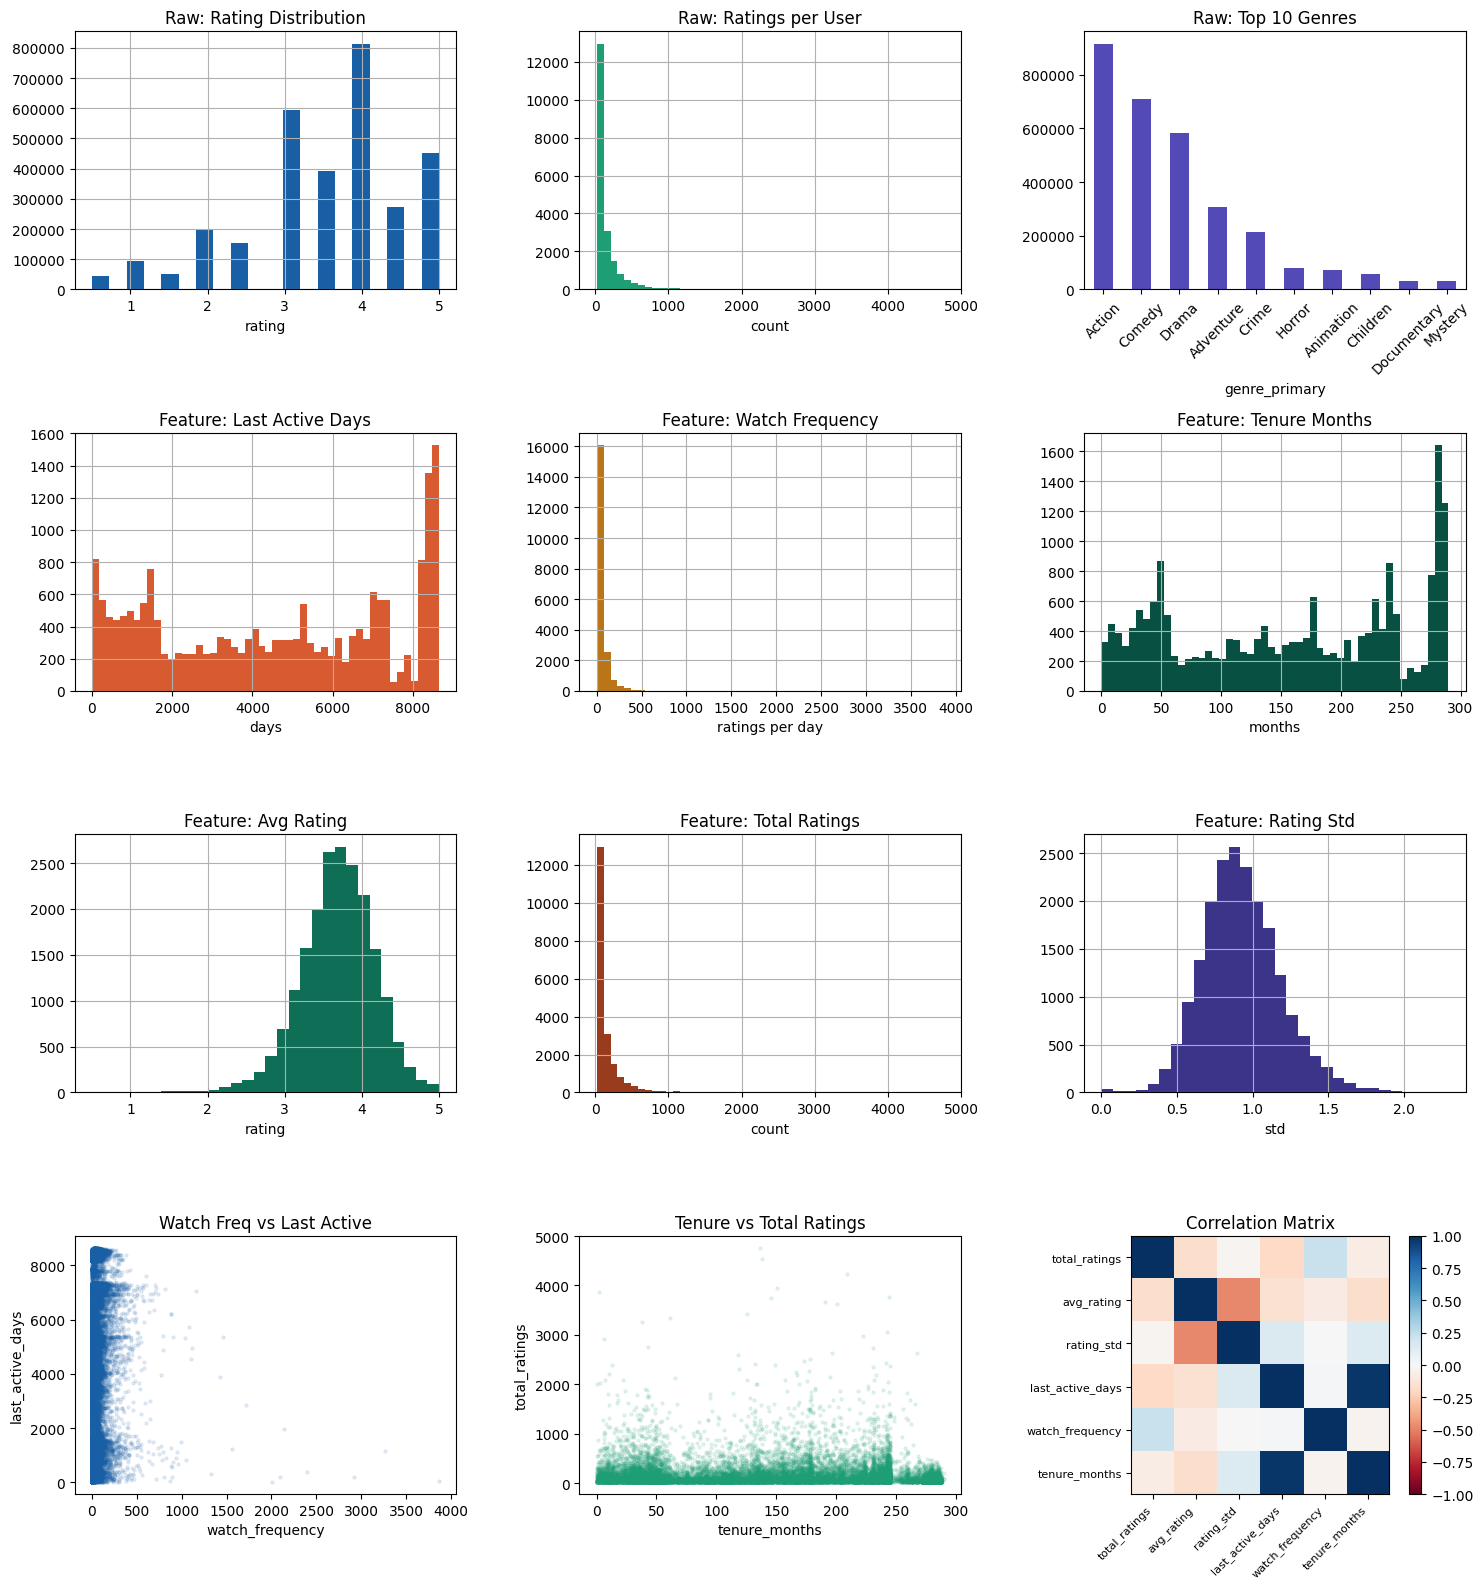

CRITICAL FEATURE RANGES — check before using in formulas
last_active_days : min=0  max=8652  mean=4522
watch_frequency  : min=0.01  max=3866.00  mean=53.34
tenure_months    : min=0  max=290  mean=158
total_ratings    : min=18  max=4764  mean=153
avg_rating       : min=0.50  max=5.00  mean=3.68

FLAG: Any feature with max >> mean needs normalisation before use in formulas


In [ ]:
# Comprehensive EDA
fig, axes = plt.subplots(4, 3, figsize=(15, 16))

# --- RAW DATA ---
# 1. Rating distribution
df['rating'].hist(ax=axes[0,0], bins=20, color='#185FA5')
axes[0,0].set_title('Raw: Rating Distribution')
axes[0,0].set_xlabel('rating')

# 2. Ratings per user
df.groupby('userId')['movieId'].count().hist(
    ax=axes[0,1], bins=50, color='#1D9E75')
axes[0,1].set_title('Raw: Ratings per User')
axes[0,1].set_xlabel('count')

# 3. Top 10 genres
df['genre_primary'].value_counts().head(10).plot(
    kind='bar', ax=axes[0,2], color='#534AB7')
axes[0,2].set_title('Raw: Top 10 Genres')
axes[0,2].tick_params(axis='x', rotation=45)

# --- DERIVED FEATURES ---
# 4. last_active_days
features['last_active_days'].hist(
    ax=axes[1,0], bins=50, color='#D85A30')
axes[1,0].set_title('Feature: Last Active Days')
axes[1,0].set_xlabel('days')

# 5. watch_frequency
features['watch_frequency'].hist(
    ax=axes[1,1], bins=50, color='#BA7517')
axes[1,1].set_title('Feature: Watch Frequency')
axes[1,1].set_xlabel('ratings per day')

# 6. tenure_months
features['tenure_months'].hist(
    ax=axes[1,2], bins=50, color='#085041')
axes[1,2].set_title('Feature: Tenure Months')
axes[1,2].set_xlabel('months')

# 7. avg_rating
features['avg_rating'].hist(
    ax=axes[2,0], bins=30, color='#0F6E56')
axes[2,0].set_title('Feature: Avg Rating')
axes[2,0].set_xlabel('rating')

# 8. total_ratings
features['total_ratings'].hist(
    ax=axes[2,1], bins=50, color='#993C1D')
axes[2,1].set_title('Feature: Total Ratings')
axes[2,1].set_xlabel('count')

# 9. genre_affinity_score — not yet computed, skip
features['rating_std'].hist(
    ax=axes[2,2], bins=30, color='#3C3489')
axes[2,2].set_title('Feature: Rating Std')
axes[2,2].set_xlabel('std')

# --- CORRELATIONS ---
# 10. last_active_days vs watch_frequency
axes[3,0].scatter(
    features['watch_frequency'],
    features['last_active_days'],
    alpha=0.1, color='#185FA5', s=5)
axes[3,0].set_xlabel('watch_frequency')
axes[3,0].set_ylabel('last_active_days')
axes[3,0].set_title('Watch Freq vs Last Active')

# 11. tenure_months vs total_ratings
axes[3,1].scatter(
    features['tenure_months'],
    features['total_ratings'],
    alpha=0.1, color='#1D9E75', s=5)
axes[3,1].set_xlabel('tenure_months')
axes[3,1].set_ylabel('total_ratings')
axes[3,1].set_title('Tenure vs Total Ratings')

# 12. Correlation heatmap
import matplotlib.colors as mcolors
num_cols = ['total_ratings','avg_rating','rating_std',
            'last_active_days','watch_frequency','tenure_months']
corr = features[num_cols].corr()
im = axes[3,2].imshow(corr, cmap='RdBu', vmin=-1, vmax=1)
axes[3,2].set_xticks(range(len(num_cols)))
axes[3,2].set_yticks(range(len(num_cols)))
axes[3,2].set_xticklabels(num_cols, rotation=45, ha='right', fontsize=8)
axes[3,2].set_yticklabels(num_cols, fontsize=8)
axes[3,2].set_title('Correlation Matrix')
plt.colorbar(im, ax=axes[3,2])

plt.tight_layout()
plt.show()

# Key stats — the critical ones for feature engineering
print("=" * 60)
print("CRITICAL FEATURE RANGES — check before using in formulas")
print("=" * 60)
print(f"last_active_days : min={features['last_active_days'].min():.0f}  "
      f"max={features['last_active_days'].max():.0f}  "
      f"mean={features['last_active_days'].mean():.0f}")
print(f"watch_frequency  : min={features['watch_frequency'].min():.2f}  "
      f"max={features['watch_frequency'].max():.2f}  "
      f"mean={features['watch_frequency'].mean():.2f}")
print(f"tenure_months    : min={features['tenure_months'].min():.0f}  "
      f"max={features['tenure_months'].max():.0f}  "
      f"mean={features['tenure_months'].mean():.0f}")
print(f"total_ratings    : min={features['total_ratings'].min()}  "
      f"max={features['total_ratings'].max()}  "
      f"mean={features['total_ratings'].mean():.0f}")
print(f"avg_rating       : min={features['avg_rating'].min():.2f}  "
      f"max={features['avg_rating'].max():.2f}  "
      f"mean={features['avg_rating'].mean():.2f}")
print()
print("FLAG: Any feature with max >> mean needs normalisation before use in formulas")

# Step # 5 Data Normalization

In [ ]:
# Normalise features with large ranges
# Informed by EDA — last_active_days max=8652, watch_frequency max=3866

# Cap outliers at 99th percentile first
watch_cap = features['watch_frequency'].quantile(0.99)
active_cap = features['last_active_days'].quantile(0.99)

print(f"watch_frequency 99th percentile  : {watch_cap:.2f}")
print(f"last_active_days 99th percentile : {active_cap:.2f}")

# Cap then normalise to 0-1
features['watch_frequency'] = (
    features['watch_frequency'].clip(0, watch_cap) / watch_cap
)

features['last_active_days'] = (
    features['last_active_days'].clip(0, active_cap) / active_cap
)

# Verify
print(f"\nwatch_frequency  — min:{features['watch_frequency'].min():.2f} max:{features['watch_frequency'].max():.2f}")
print(f"last_active_days — min:{features['last_active_days'].min():.2f} max:{features['last_active_days'].max():.2f}")

watch_frequency 99th percentile  : 393.00
last_active_days 99th percentile : 8591.00

watch_frequency  — min:0.00 max:1.00
last_active_days — min:0.00 max:1.00


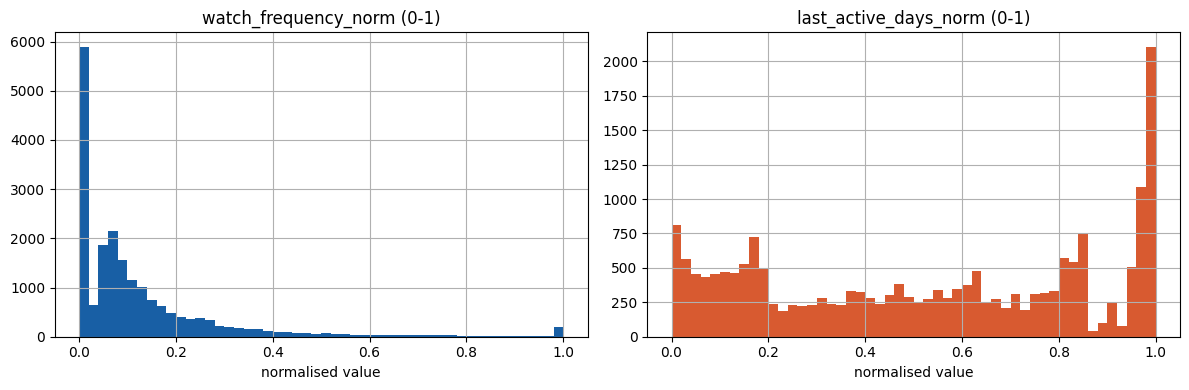

In [ ]:
# Plot normalised distributions
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

features['watch_frequency'].hist(
    ax=axes[0], bins=50, color='#185FA5')
axes[0].set_title('watch_frequency_norm (0-1)')
axes[0].set_xlabel('normalised value')

features['last_active_days'].hist(
    ax=axes[1], bins=50, color='#D85A30')
axes[1].set_title('last_active_days_norm (0-1)')
axes[1].set_xlabel('normalised value')

plt.tight_layout()
plt.show()

# Step # 4 Genre Affinity Scores Per User


total_ratings 99th percentile: 1222
count    19998.00
mean        38.72
std         10.89
min         16.10
25%         31.00
50%         36.40
75%         43.90
max        100.00
Name: genre_affinity_score, dtype: float64


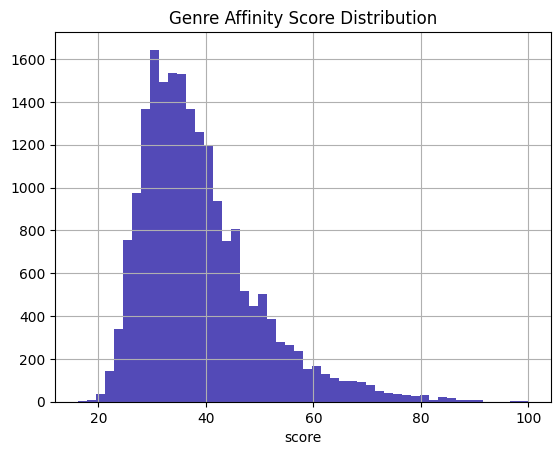

In [ ]:
# Genre affinity scores
# Drop any existing genre columns first
features = features.drop(columns=[c for c in features.columns
                                   if 'genre' in c.lower()], errors='ignore')

# Top genre per user
genre_counts = df.groupby(['userId', 'genre_primary']).size().reset_index(name='cnt')
top_genre = genre_counts.sort_values('cnt', ascending=False).groupby('userId').first()
top_genre.columns = ['top_genre', 'top_genre_cnt']

features = features.merge(top_genre, on='userId', how='left')

# Cap total_ratings at 99th percentile first
ratings_cap = features['total_ratings'].quantile(0.99)
print(f"total_ratings 99th percentile: {ratings_cap:.0f}")

# Compute affinity as capped percentage
features['genre_affinity_score'] = (
    features['top_genre_cnt'] /
    features['total_ratings'].clip(1, ratings_cap) * 100
).clip(0, 100).round(1)

features['genre_encoded'] = pd.Categorical(features['top_genre']).codes

# Check distribution
print(features['genre_affinity_score'].describe().round(2))
features['genre_affinity_score'].hist(bins=50, color='#534AB7')
plt.title('Genre Affinity Score Distribution')
plt.xlabel('score')
plt.show()

# Step # 5 Synthetic Billing & Plan Tier Signals

In [ ]:
# Assign plan tier based on watch frequency (realistic proxy)
def assign_plan(freq):
    if freq > 0.5:   return 'Premium'
    elif freq > 0.1: return 'Standard'
    else:            return 'Basic'

plan_price = {'Basic': 9.99, 'Standard': 15.49, 'Premium': 22.99}
plan_num   = {'Basic': 1,    'Standard': 2,      'Premium': 3}

features['plan_tier']    = features['watch_frequency'].apply(assign_plan)
features['plan_price']   = features['plan_tier'].map(plan_price)
features['plan_encoded'] = features['plan_tier'].map(plan_num)

# # Acquisition channel (realistic distribution)
# features['acq_channel'] = np.random.choice(
#     ['organic', 'paid_social', 'bundle', 'trial'],
#     size=len(features),
#     p=[0.45, 0.25, 0.20, 0.10]
# )
# features['acq_encoded'] = pd.Categorical(features['acq_channel']).codes

# print(features['plan_tier'].value_counts())
# print(features['acq_channel'].value_counts())

In [ ]:
# Assign acquisition channel based on behaviour — not randomly
def assign_channel(row):
    # Heavy watchers — more likely organic (found it themselves, committed)
    # Light watchers — more likely trial or paid social
    # High genre affinity — more likely organic

    watch = row['watch_frequency']
    affinity = row['genre_affinity_score']

    if watch > 0.6 and affinity > 60:
        # Heavy engaged watcher — almost certainly organic
        return np.random.choice(
            ['organic', 'paid_social', 'bundle', 'trial'],
            p=[0.70, 0.15, 0.10, 0.05]
        )
    elif watch > 0.3:
        # Medium watcher
        return np.random.choice(
            ['organic', 'paid_social', 'bundle', 'trial'],
            p=[0.45, 0.25, 0.20, 0.10]
        )
    else:
        # Light watcher — likely trial or paid social
        return np.random.choice(
            ['organic', 'paid_social', 'bundle', 'trial'],
            p=[0.20, 0.30, 0.20, 0.30]
        )

features['acq_channel'] = features.apply(assign_channel, axis=1)
features['acq_encoded'] = pd.Categorical(features['acq_channel']).codes

print(features['acq_channel'].value_counts())

acq_channel
paid_social    6026
trial          5447
organic        4553
bundle         3972
Name: count, dtype: int64


# Step # 6 Simulate Churn Labels (Markov-Based)

In [ ]:
# Churn probability driven by real behavioural signals
# Add channel effect to churn_prob
channel_effect = {
    'organic'    : -0.05,
    'paid_social': +0.02,
    'bundle'     : -0.02,
    'trial'      : +0.08
}

def churn_prob(row):
    p = (0.8 * row['last_active_days']
       - 0.5 * row['watch_frequency']
       - 0.2 * (row['genre_affinity_score'] / 100.0)
       - 0.1 * row['plan_encoded'])
    p += channel_effect.get(row['acq_channel'], 0)
    return np.clip(p, 0.05, 0.95)

features['churn_prob'] = features.apply(churn_prob, axis=1)
features['churned']    = (
    np.random.random(len(features)) < features['churn_prob']
).astype(int)

# Markov state
def markov_state(row):
    if row['churned'] == 0:
        return 'on_service'
    elif row['last_active_days'] < 0.16:  # 0.16 ≈ 60 days on 0-1 scale
        return 'off_service_recent'
    else:
        return 'off_service_long'


features['markov_state'] = features.apply(markov_state, axis=1)
print(features['markov_state'].value_counts())
print(f"Churn rate: {features['churned'].mean():.1%}")


markov_state
on_service            15382
off_service_long       4417
off_service_recent      199
Name: count, dtype: int64
Churn rate: 23.1%


# Step # 7 Compute Markov Chain iLTV

In [ ]:
# Netflix WWW '22 methodology — iLTV = on-service LTV - counterfactual LTV
discount_rate  = 0.01   # monthly discount rate
horizon_months = 24     # 2-year horizon

def compute_iltv(row):
    p_retain  = 1 - row['churn_prob']
    p_rejoin  = np.clip(0.15 + row['genre_affinity_score'] * 0.001, 0.05, 0.45)
    price     = row['plan_price']

    # On-service LTV: discounted sum of future payments
    ltv_on = 0
    p_alive = 1.0
    for t in range(1, horizon_months + 1):
        ltv_on  += p_alive * price / (1 + discount_rate) ** t
        p_alive *= p_retain

    # Counterfactual off-service LTV (Markov rejoin probability)
    ltv_off = 0
    p_still_off = 1.0
    for t in range(1, horizon_months + 1):
        ltv_off    += p_still_off * p_rejoin * price / (1 + discount_rate) ** t
        p_still_off *= (1 - p_rejoin)

    naive_ltv = round(ltv_on, 2)
    iltv      = round(max(ltv_on - ltv_off, 0), 2)
    return pd.Series({'naive_ltv': naive_ltv, 'iltv': iltv,
                       'p_rejoin': round(p_rejoin, 3)})

iltv_cols = features.apply(compute_iltv, axis=1)
features  = pd.concat([features, iltv_cols], axis=1)

avg_naive = features['naive_ltv'].mean()
avg_iltv  = features['iltv'].mean()
overstate = avg_naive / avg_iltv

print(f"Avg naive LTV : ${avg_naive:.2f}")
print(f"Avg iLTV      : ${avg_iltv:.2f}")
print(f"Overstatement : {overstate:.1f}x")

Avg naive LTV : $96.75
Avg iLTV      : $84.93
Overstatement : 1.1x


# Step # 8 Save feature table to CSV

In [ ]:
# Save — use this as input to all downstream notebooks
features.to_csv('subscriber_features.csv', index=False)
print(f"Saved subscriber_features.csv — {features.shape}")
print(f"Columns: {list(features.columns)}")

# Quick sanity check
features[['userId', 'plan_tier', 'top_genre',
          'churn_prob', 'naive_ltv', 'iltv',
          'markov_state']].head(10)

Saved subscriber_features.csv — (19998, 22)
Columns: ['userId', 'total_ratings', 'avg_rating', 'rating_std', 'last_active_days', 'watch_frequency', 'tenure_months', 'top_genre', 'top_genre_cnt', 'genre_affinity_score', 'genre_encoded', 'plan_tier', 'plan_price', 'plan_encoded', 'acq_channel', 'acq_encoded', 'churn_prob', 'churned', 'markov_state', 'naive_ltv', 'iltv', 'p_rejoin']


,userId,plan_tier,top_genre,churn_prob,naive_ltv,iltv,markov_state
0,13,Basic,Action,0.161425,57.61,48.14,on_service
1,21,Standard,Action,0.050000,198.80,184.09,off_service_recent
2,25,Standard,Action,0.404950,37.33,22.75,on_service
3,34,Basic,Action,0.140763,64.89,55.46,on_service
4,35,Basic,Comedy,0.050000,128.21,118.78,on_service
5,45,Standard,Comedy,0.443119,34.19,19.57,on_service
6,85,Standard,Comedy,0.388784,38.84,24.17,off_service_long
7,90,Basic,Drama,0.543426,18.05,8.65,on_service
8,97,Basic,Action,0.324849,29.83,20.38,off_service_long
9,98,Standard,Comedy,0.050000,198.80,184.20,on_service
